# G6V1 - Integración de datos desde CSV, Excel, JSON y SQL relacional

**Versión aprendiz.**

En este notebook se integran cuatro fuentes estructuradas para construir un dataset único por cliente.

## 1. Propósito

Construir un dataset integrado usando `ID_Cliente` como llave común. La integración combina datos maestros, transacciones de compras, interacciones web y satisfacción del cliente.

Se realiza la conexión entre python con SQL utilizando la librería pyodbc, además de importar las librerias necesarias par realizar la integración de los datos desde las diferentes fuentes. con el fin de construir un único dataset por cada cliente.

In [1]:
import pyodbc
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../03_data")
OUT_DIR = Path("../08_revision/evidencias")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

DATA_DIR: C:\Users\HP\Desktop\EntregablesMayoH\03_data
OUT_DIR: C:\Users\HP\Desktop\EntregablesMayoH\08_revision\evidencias


Paracargar los archivos en los cuatro formatos y que no presente errores al ejecutar el notebook fue necesario subir esos archivos al repositorio de github, para luego reemplazarlas een los respectivos 

## 2. Carga de fuentes

Se cargan archivos en cuatro formatos: CSV, Excel, JSON y SQL relacional.

In [2]:
#================================================================
#Carga de datos desde multiples fuentes: CSV, Excel, JSON y SQL Server  
#========================================================================
clientes = pd.read_csv("https://raw.githubusercontent.com/jaidisplata/PRODEMIA/refs/heads/main/6-Integracion_Datos_Multiples_Fuentes/03_data/clientes.csv")

try:
    compras = pd.read_excel("https://github.com/jaidisplata/PRODEMIA/blob/main/6-Integracion_Datos_Multiples_Fuentes/03_data/compras.xlsx?raw=true")
except Exception as e:
    print("No se pudo leer compras.xlsx. Se usará compras_respaldo.csv. Detalle:", e)
    compras = pd.read_csv("https://raw.githubusercontent.com/jaidisplata/PRODEMIA/refs/heads/main/6-Integracion_Datos_Multiples_Fuentes/03_data/compras_respaldo.csv")

web = pd.read_json("https://raw.githubusercontent.com/jaidisplata/PRODEMIA/main/6-Integracion_Datos_Multiples_Fuentes/03_data/interacciones_web.json")


conexion = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\SQLEXPRESS;"
    "DATABASE=satisfaccion_clientes;"
    "Trusted_Connection=yes;" # Reemplaza UID y PWD por esto
    "TrustServerCertificate=yes;"
)

print("Conectado a SQL Server exitosamente.")

SQL = """
SELECT *
FROM empresa_integracion
"""

satisfaccion = pd.read_sql(SQL, conexion)

display(satisfaccion)

print("clientes:", clientes.shape)
print("compras:", compras.shape)
print("web:", web.shape)
print("satisfaccion:", satisfaccion.shape)




Conectado a SQL Server exitosamente.


C:\Users\HP\AppData\Local\Temp\ipykernel_10780\580706831.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  satisfaccion = pd.read_sql(SQL, conexion)


,ID_Cliente,Satisfaccion,QuejasUltimos6M
0,C0001,Media,2
1,C0002,Baja,1
2,C0003,Alta,4
3,C0004,Media,1
4,C0005,Media,1
...,...,...,...
155,C0156,Media,0
156,C0157,Baja,1
157,C0158,Alta,0
158,C0159,Media,3


clientes: (160, 6)
compras: (590, 6)
web: (160, 4)
satisfaccion: (160, 3)


## 3. Diagnóstico inicial

Antes de unir, se revisa la calidad de cada fuente.

In [3]:
#============================================================
#Exploración inicial de las fuentes de datos
#Se revisan dimensiones, duplicados y valores nulos antes de 
#iniciar el proceso de integración
#=============================================================  

fuentes = {
    "clientes": clientes,
    "compras": compras,
    "web": web,
    "satisfaccion": satisfaccion
}

for nombre, df in fuentes.items():
    print("\nFuente:", nombre)
    print("Dimensiones:", df.shape)
    print("Duplicados:", df.duplicated().sum())
    print("Nulos por columna:")
    print(df.isna().sum())


Fuente: clientes
Dimensiones: (160, 6)
Duplicados: 0
Nulos por columna:
ID_Cliente        0
Edad              0
Ciudad            0
Segmento          0
FechaRegistro     0
CanalPreferido    0
dtype: int64

Fuente: compras
Dimensiones: (590, 6)
Duplicados: 3
Nulos por columna:
ID_Cliente           0
FechaCompra          0
CategoriaProducto    0
Cantidad             0
ValorUnitario        0
Descuento            0
dtype: int64

Fuente: web
Dimensiones: (160, 4)
Duplicados: 0
Nulos por columna:
ID_Cliente                 0
VisitasWebUltimoMes        0
TiempoPromedioSesionMin    0
FuenteWeb                  0
dtype: int64

Fuente: satisfaccion
Dimensiones: (160, 3)
Duplicados: 0
Nulos por columna:
ID_Cliente         0
Satisfaccion       0
QuejasUltimos6M    0
dtype: int64


### Análisis

Responda: ¿cuál fuente tiene mayor granularidad? ¿Cuál fuente es maestro de datos? ¿Qué problemas de calidad se observan?

La fuente con mayor granularidad es compras.xlsx, ya que registra cada transacción realizada por los clientes, por lo que un mismo cliente puede aparecer varias veces.

La fuente maestra es clientes.csv, debido a que la información principal de cada cliente constituye la base para integrar las demás fuentes  mediantes mediante la llave ID_Cliente.

En cuanto a la calidad de los datos, el diagnóstico mostró que la única incosnistencia corresponde a la presencia de tres registros duplicados en la fuente de compras. no se identificaron valores nulos en ninguna de las fuentes y las demás tablas no presentan registros duplicados.

## 4. Normalización de llaves y fechas

La llave `ID_Cliente` debe quedar limpia y comparable en todas las fuentes.

In [4]:
#===============================================================
# Estandarización de formatos
# se normaliza el identificador del cliente y se convierten las 
# columnas de fecha al tipo datetime para garantizar una correcta
# integración entre las fuentes
#===============================================================

for df in [clientes, compras, web, satisfaccion]:
    df["ID_Cliente"] = df["ID_Cliente"].astype(str).str.strip().str.upper()

clientes["FechaRegistro"] = pd.to_datetime(clientes["FechaRegistro"], errors="coerce")
compras["FechaCompra"] = pd.to_datetime(compras["FechaCompra"], errors="coerce")

#======================================================================
# Revisión y Tratamiento de registros duplicados en la fuente compras
#=====================================================================

# Crear una copia para conservar la fuente original
compras_limpias = compras.copy()

# Número de registros duplicados encontrados
print("Duplicados antes del tratamiento:", compras_limpias.duplicated().sum())

# Mostrarlos registros duplicados
display(compras_limpias[compras_limpias.duplicated(keep=False)])

# Eliminar los registros duplicados
compras_limpias = compras_limpias.drop_duplicates()

# Reemplazar la fuente original por la versión limpia
compras = compras_limpias.copy()

# Verificar el resultado
print("Duplicados despúes del tratamiento:", compras_limpias.duplicated().sum())

Duplicados antes del tratamiento: 3


,ID_Cliente,FechaCompra,CategoriaProducto,Cantidad,ValorUnitario,Descuento
23,C0007,2025-09-21,Servicios,3,69953,0.00
284,C0083,2025-03-28,Alimentos,2,128178,0.00
579,C0159,2025-11-21,Alimentos,3,25149,0.05
587,C0159,2025-11-21,Alimentos,3,25149,0.05
588,C0083,2025-03-28,Alimentos,2,128178,0.00
589,C0007,2025-09-21,Servicios,3,69953,0.00


Duplicados despúes del tratamiento: 0


## 5. Validación de correspondencia

Se identifican transacciones que no tienen cliente asociado. Esto es importante para la trazabilidad.

In [5]:
ids_clientes = set(clientes["ID_Cliente"])
compras_sin_cliente = compras[~compras["ID_Cliente"].isin(ids_clientes)]

print("Compras con ID_Cliente inexistente en clientes:", len(compras_sin_cliente))
compras_sin_cliente.head()

Compras con ID_Cliente inexistente en clientes: 2


,ID_Cliente,FechaCompra,CategoriaProducto,Cantidad,ValorUnitario,Descuento
585,C9999,2025-08-10,Tecnología,1,150000,0.05
586,C8888,2025-09-12,Servicios,2,60000,0.00


In [6]:
ids_clientes = set(clientes["ID_Cliente"])
compras_sin_cliente = compras[~compras["ID_Cliente"].isin(ids_clientes)]

print("Compras con ID_Cliente inexistente en clientes:", len(compras_sin_cliente))
compras_sin_cliente.head()

Compras con ID_Cliente inexistente en clientes: 2


,ID_Cliente,FechaCompra,CategoriaProducto,Cantidad,ValorUnitario,Descuento
585,C9999,2025-08-10,Tecnología,1,150000,0.05
586,C8888,2025-09-12,Servicios,2,60000,0.00


## 6. Agregación de compras por cliente

Como compras tiene varias filas por cliente, primero se agregan las transacciones para evitar duplicar clientes en el dataset final.

In [7]:
compras["ValorNeto"] = compras["Cantidad"] * compras["ValorUnitario"] * (1 - compras["Descuento"])
compras_validas = compras[compras["ID_Cliente"].isin(ids_clientes)].copy()

compras_agregadas = (
    compras_validas
    .groupby("ID_Cliente")
    .agg(
        TotalCompras=("ID_Cliente", "count"),
        ValorTotalCompras=("ValorNeto", "sum"),
        TicketPromedio=("ValorNeto", "mean"),
        UltimaCompra=("FechaCompra", "max")
    )
    .reset_index()
)

compras_agregadas["ValorTotalCompras"] = compras_agregadas["ValorTotalCompras"].round(2)
compras_agregadas["TicketPromedio"] = compras_agregadas["TicketPromedio"].round(2)

compras_agregadas.head()

,ID_Cliente,TotalCompras,ValorTotalCompras,TicketPromedio,UltimaCompra
0,C0001,1,587030.4,587030.40,2025-10-23
1,C0002,1,74219.7,74219.70,2025-08-01
2,C0003,2,307306.9,153653.45,2025-10-23
3,C0004,4,726085.8,181521.45,2025-12-19
4,C0005,5,1674417.2,334883.44,2025-11-20


In [8]:
#==========================================================
# Integración de las fuentes de datos
#==========================================================

# Se integra la información de clientes, compras, interacciones web y satisfacción
# utilizando ID_Cliente como llave común.

dataset = clientes.merge(compras_agregadas, on="ID_Cliente", how="left")
dataset = dataset.merge(web, on="ID_Cliente", how="left")
dataset = dataset.merge(satisfaccion, on="ID_Cliente", how="left")

# Completar valores nulos generados por clientes sin compras
dataset["TotalCompras"] = dataset["TotalCompras"].fillna(0).astype(int)
dataset["ValorTotalCompras"] = dataset["ValorTotalCompras"].fillna(0)
dataset["TicketPromedio"] = dataset["TicketPromedio"].fillna(0)

print("Dataset integrado:", dataset.shape)
dataset.head()

Dataset integrado: (160, 15)


,ID_Cliente,Edad,Ciudad,Segmento,FechaRegistro,CanalPreferido,TotalCompras,ValorTotalCompras,TicketPromedio,UltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,FuenteWeb,Satisfaccion,QuejasUltimos6M
0,C0001,56,Cali,Medio,2024-08-02,App,1,587030.4,587030.40,2025-10-23,3,2.81,Anuncio pagado,Media,2
1,C0002,46,Cartagena,Básico,2024-08-22,App,1,74219.7,74219.70,2025-08-01,4,0.80,Redes sociales,Baja,1
2,C0003,32,Cartagena,Básico,2025-08-10,App,2,307306.9,153653.45,2025-10-23,4,5.64,Referido,Alta,4
3,C0004,60,Barranquilla,Medio,2024-01-09,Web,4,726085.8,181521.45,2025-12-19,6,1.96,Orgánico,Media,1
4,C0005,25,Cartagena,Medio,2024-03-14,Web,5,1674417.2,334883.44,2025-11-20,9,4.16,Email,Media,1


In [9]:
print(clientes["ID_Cliente"].head())
print(satisfaccion["ID_Cliente"].head())

0    C0001
1    C0002
2    C0003
3    C0004
4    C0005
Name: ID_Cliente, dtype: object
0    C0001
1    C0002
2    C0003
3    C0004
4    C0005
Name: ID_Cliente, dtype: object


In [22]:
print(clientes["ID_Cliente"].dtype)
print(satisfaccion["ID_Cliente"].dtype)

object
object


In [11]:
coincidencias = clientes["ID_Cliente"].isin(satisfaccion["ID_Cliente"]).sum()
print("Clientes con coincidencia:", coincidencias)

Clientes con coincidencia: 160


In [12]:
display(clientes.head())

,ID_Cliente,Edad,Ciudad,Segmento,FechaRegistro,CanalPreferido
0,C0001,56,Cali,Medio,2024-08-02,App
1,C0002,46,Cartagena,Básico,2024-08-22,App
2,C0003,32,Cartagena,Básico,2025-08-10,App
3,C0004,60,Barranquilla,Medio,2024-01-09,Web
4,C0005,25,Cartagena,Medio,2024-03-14,Web


In [13]:
print(satisfaccion.head(10))

  ID_Cliente Satisfaccion QuejasUltimos6M
0      C0001        Media               2
1      C0002         Baja               1
2      C0003         Alta               4
3      C0004        Media               1
4      C0005        Media               1
5      C0006         Baja               0
6      C0007         Alta               3
7      C0008         Alta               0
8      C0009         Alta               0
9      C0010        Media               1


## 7. Integración de fuentes

Se usa `merge` tipo `left` para conservar todos los clientes del maestro.

In [14]:
dataset = clientes.merge(compras_agregadas, on="ID_Cliente", how="left")
dataset = dataset.merge(web, on="ID_Cliente", how="left")
dataset = dataset.merge(satisfaccion, on="ID_Cliente", how="left")

dataset["TotalCompras"] = dataset["TotalCompras"].fillna(0).astype(int)
dataset["ValorTotalCompras"] = dataset["ValorTotalCompras"].fillna(0)
dataset["TicketPromedio"] = dataset["TicketPromedio"].fillna(0)

print("Dataset integrado:", dataset.shape)
dataset.head()

Dataset integrado: (160, 15)


,ID_Cliente,Edad,Ciudad,Segmento,FechaRegistro,CanalPreferido,TotalCompras,ValorTotalCompras,TicketPromedio,UltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,FuenteWeb,Satisfaccion,QuejasUltimos6M
0,C0001,56,Cali,Medio,2024-08-02,App,1,587030.4,587030.40,2025-10-23,3,2.81,Anuncio pagado,Media,2
1,C0002,46,Cartagena,Básico,2024-08-22,App,1,74219.7,74219.70,2025-08-01,4,0.80,Redes sociales,Baja,1
2,C0003,32,Cartagena,Básico,2025-08-10,App,2,307306.9,153653.45,2025-10-23,4,5.64,Referido,Alta,4
3,C0004,60,Barranquilla,Medio,2024-01-09,Web,4,726085.8,181521.45,2025-12-19,6,1.96,Orgánico,Media,1
4,C0005,25,Cartagena,Medio,2024-03-14,Web,5,1674417.2,334883.44,2025-11-20,9,4.16,Email,Media,1


# CONVERSIÓN DEL TIPO DE DATOS QuejasUltimos6M

In [15]:
# ===========================================================
# Conversión y validación del tipo de dato
# Se convierte la variable QuejasUltimos6M a formato numérico
# para asegurar consistencia en el análisis y las agregaciones.
# ===========================================================

dataset["QuejasUltimos6M"] = pd.to_numeric(
    dataset["QuejasUltimos6M"],
    errors="coerce"
)

# Si no existen valores nulos después de la conversión,
# la variable se convierte a tipo entero.
if dataset["QuejasUltimos6M"].isna().sum() == 0:
    dataset["QuejasUltimos6M"] = dataset["QuejasUltimos6M"].astype("int64")

## 8. Validación del dataset integrado

In [16]:
print("Duplicados por ID_Cliente:", dataset["ID_Cliente"].duplicated().sum())
print("\nNulos finales:")
print(dataset.isna().sum())
print("\nFilas y columnas:", dataset.shape)

Duplicados por ID_Cliente: 0

Nulos finales:
ID_Cliente                  0
Edad                        0
Ciudad                      0
Segmento                    0
FechaRegistro               0
CanalPreferido              0
TotalCompras                0
ValorTotalCompras           0
TicketPromedio              0
UltimaCompra               10
VisitasWebUltimoMes         0
TiempoPromedioSesionMin     0
FuenteWeb                   0
Satisfaccion                0
QuejasUltimos6M             0
dtype: int64

Filas y columnas: (160, 15)


In [17]:
#==========================================================
# Verificación de registros con fecha de última compra nula
#==========================================================

# Los valores nulos en la columna UltimaCompra corresponden
# a clientes que no registran compras, por lo que se consideran
# válidos porque es un resultado que se de en el contexto del negocio 
# por lo que no requieren tratamiento.

dataset.loc[
    dataset["UltimaCompra"].isna(),
    ["ID_Cliente", "TotalCompras", "ValorTotalCompras", "UltimaCompra"]
]

,ID_Cliente,TotalCompras,ValorTotalCompras,UltimaCompra
21,C0022,0,0.0,NaT
40,C0041,0,0.0,NaT
49,C0050,0,0.0,NaT
67,C0068,0,0.0,NaT
77,C0078,0,0.0,NaT
89,C0090,0,0.0,NaT
105,C0106,0,0.0,NaT
107,C0108,0,0.0,NaT
119,C0120,0,0.0,NaT
120,C0121,0,0.0,NaT


## 9. Indicadores básicos

In [18]:
indicadores_segmento = (
    dataset.groupby("Segmento")
    .agg(
        Clientes=("ID_Cliente", "count"),
        ValorTotal=("ValorTotalCompras", "sum"),
        TicketPromedio=("TicketPromedio", "mean"),
        QuejasPromedio=("QuejasUltimos6M", "mean")
    )
    .round(2)
    .reset_index()
)

indicadores_ciudad = (
    dataset.groupby("Ciudad")
    .agg(
        Clientes=("ID_Cliente", "count"),
        ValorTotal=("ValorTotalCompras", "sum"),
        VisitasPromedio=("VisitasWebUltimoMes", "mean")
    )
    .round(2)
    .reset_index()
)

display(indicadores_segmento)
display(indicadores_ciudad)

,Segmento,Clientes,ValorTotal,TicketPromedio,QuejasPromedio
0,Básico,71,46753858.50,258431.86,1.13
1,Medio,64,70077703.20,270864.21,1.00
2,Premium,25,51662389.15,280568.21,1.48


,Ciudad,Clientes,ValorTotal,VisitasPromedio
0,Barranquilla,28,24483849.70,5.96
1,Bogotá,31,33896792.40,6.26
2,Cali,26,33351608.05,5.88
3,Cartagena,42,40552306.70,5.86
4,Medellín,33,36209394.00,6.03


## 10. Visualización

<Figure size 800x500 with 0 Axes>

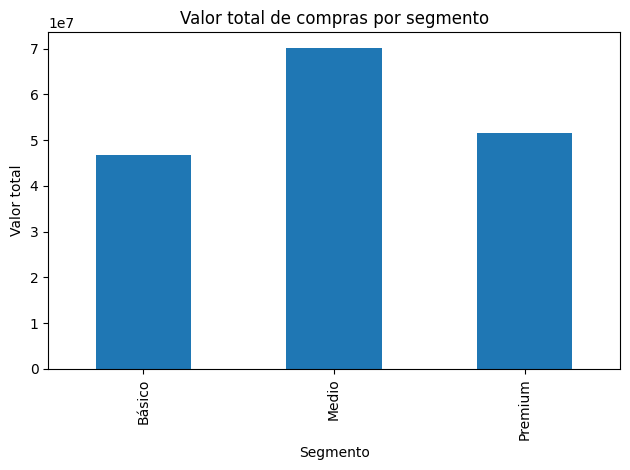

<Figure size 800x500 with 0 Axes>

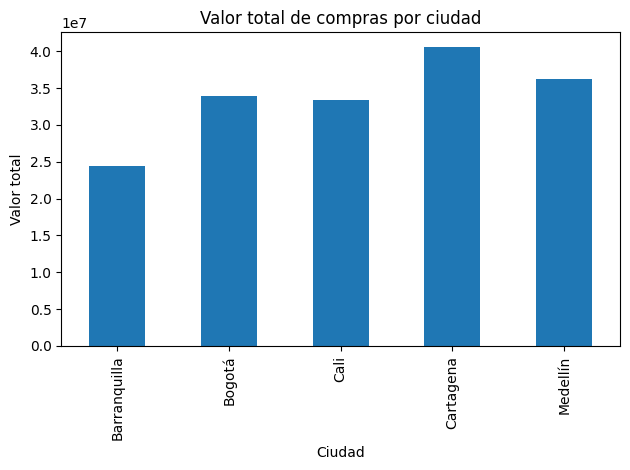

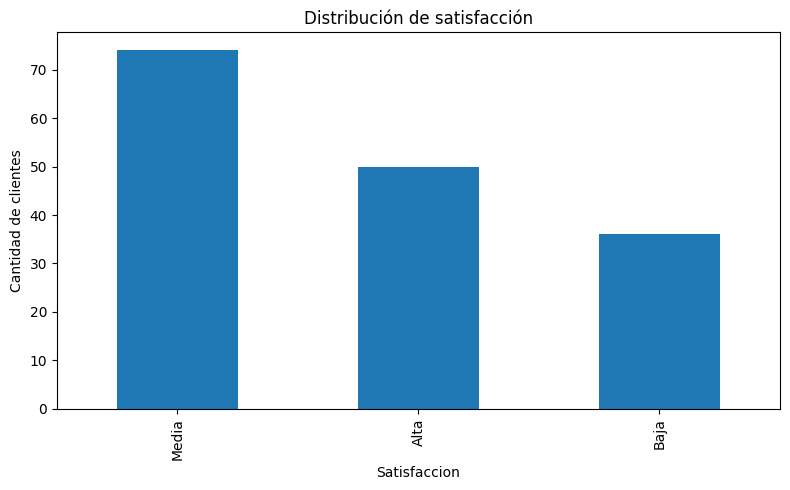

In [19]:
plt.figure(figsize=(8, 5))
indicadores_segmento.plot(kind="bar", x="Segmento", y="ValorTotal", legend=False)
plt.title("Valor total de compras por segmento")
plt.xlabel("Segmento")
plt.ylabel("Valor total")
plt.tight_layout()
plt.savefig(OUT_DIR / "valor_total_por_segmento.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
indicadores_ciudad.plot(kind="bar", x="Ciudad", y="ValorTotal", legend=False)
plt.title("Valor total de compras por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Valor total")
plt.tight_layout()
plt.savefig(OUT_DIR / "valor_total_por_ciudad.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
dataset["Satisfaccion"].value_counts().plot(kind="bar")
plt.title("Distribución de satisfacción")
plt.xlabel("Satisfaccion")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.savefig(OUT_DIR / "distribucion_Satisfaccion.png", dpi=150)
plt.show()

## 11. Exportación de resultados

In [20]:
dataset.to_csv(OUT_DIR / "dataset_integrado_clientes.csv", index=False, encoding="utf-8-sig")
indicadores_segmento.to_csv(OUT_DIR / "indicadores_segmento.csv", index=False, encoding="utf-8-sig")
indicadores_ciudad.to_csv(OUT_DIR / "indicadores_ciudad.csv", index=False, encoding="utf-8-sig")

reporte = []
reporte.append("REPORTE DE VALIDACIÓN G6V1")
reporte.append("=" * 40)
reporte.append(f"Clientes fuente: {len(clientes)}")
reporte.append(f"Compras fuente: {len(compras)}")
reporte.append(f"Compras sin cliente: {len(compras_sin_cliente)}")
reporte.append(f"Filas dataset integrado: {len(dataset)}")
reporte.append(f"Columnas dataset integrado: {dataset.shape[1]}")
reporte.append(f"Duplicados por ID_Cliente en dataset final: {dataset['ID_Cliente'].duplicated().sum()}")

with open(OUT_DIR / "reporte_validacion_integracion.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(reporte))

print("Archivos exportados en:", OUT_DIR)

Archivos exportados en: ..\08_revision\evidencias


## 12. Preguntas de análisis

1. ¿Por qué se agregaron las compras antes de integrarlas?

Se agregaron las compras antes de realizar la integración porque la tabla conpras tiene una mayor granularidad que la tabla clientes, la tabla de comprar registra múltiples transacciones para un mismo client ya que si se unen ambas tablas directamente, un cliente aparecería repetido varias veces en el dataset final. es por ello que en el noteboo las compras se agruparon mediante groupy("ID_Cliente"), calculando variables como TotalCompras, ValorTotalCompras, TicketPromedio y UltimaCompra. de esta manera se pudo obtener una sola fila por cliente, permitiendo una integración correcta con la fuente maestra.

2. ¿Qué significa que existan compras con ID_Cliente inexistente?
Significa que eisten registros de compras cuyo ID_Cliente no aparece en la tabla maestra de clientes. Esto representa una inconsistencia en la calidad de los datos, ya que no es posible asociar esas compras con un cliente válido.

3. ¿Qué variables del dataset integrado podrían servir para análisis comercial?
El dataset integrado contiene variables que permiten analizar el comportamiento de los clientes desde diferentes perspectivas. Algunas de las más relevantes son:

Segmento: permite identificar grupos de clientes y diseñar estrategias comerciales diferenciadas.
Ciudad: facilita el análisis geográfico para identificar mercados con mayor o menor desempeño.
CanalPreferido: ayuda a conocer el canal de comunicación o compra preferido por los clientes para optimizar campañas.
TotalCompras: permite identificar la frecuencia de compra de cada cliente.
ValorTotalCompras: sirve para determinar el valor económico aportado por cada cliente.
TicketPromedio: facilita el análisis del gasto promedio por compra.
UltimaCompra: permite evaluar la actividad reciente de los clientes e identificar posibles casos de inactividad.
VisitasWebUltimoMes y TiempoPromedioSesionMin: ayudan a analizar el comportamiento digital y el nivel de interacción con la empresa.
Satisfaccion y QuejasUltimos6M: permiten evaluar la experiencia del cliente y detectar oportunidades de mejora en el servicio.

En conjunto, estas variables permiten realizar análisis de comportamiento, segmentación de clientes, evaluación del desempeño comercial y seguimiento de la satisfacción del cliente.

4. ¿Qué limitaciones tendría este dataset si se usara para IA?
Aunque el dataset es adecuado para realizar análisis exploratorio e integración de datos, presenta algunas limitaciones para desarrollar modelos de inteligencia artificial:

El número de registros es relativamente pequeño (160 clientes), lo que puede limitar la capacidad de generalización de algunos modelos.
Existen clientes sin historial de compras, por lo que algunas variables como UltimaCompra presentan valores nulos que representan una condición válida del negocio.
El conjunto de datos corresponde a un único período de tiempo y no incluye información histórica suficiente para analizar tendencias o realizar predicciones temporales.
No incorpora variables externas (por ejemplo, información económica, campañas de marketing o competencia) que podrían mejorar el desempeño de modelos predictivos.
Algunas variables categóricas requerirían una transformación previa antes de ser utilizadas en algoritmos de aprendizaje automático.

5. ¿Qué controles de calidad agregaría en una empresa real?

En un entorno empresarial se recomienda implementar controles de calidad para garantizar la confiabilidad de los datos. Entre ellos:
Verificar que cada ID_Cliente sea único y válido.
Validar que las fechas tengan un formato correcto y que no existan fechas futuras cuando no correspondan.
Controlar la existencia de valores nulos en variables críticas y determinar si representan errores o condiciones válidas del negocio.
Detectar y eliminar registros duplicados durante los procesos de integración.
Validar que variables numéricas como TotalCompras, ValorTotalCompras y TicketPromedio no presenten valores negativos o inconsistentes.
Verificar la consistencia entre variables relacionadas; por ejemplo, que un cliente con TotalCompras = 0 tenga ValorTotalCompras = 0 y UltimaCompra nula, como ocurrió en este proyecto.
Implementar controles automáticos durante los procesos de carga (ETL) para detectar errores antes de integrar la información en la base de datos.

Estas prácticas contribuyen a mantener la calidad, consistencia e integridad de los datos, mejorando la confiabilidad de los análisis posteriores.

In [21]:
OUT_DIR = Path("08_revision/evidencias")